In [1]:
print("Sales Forecast Project Started")

Sales Forecast Project Started


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding='latin1')

In [4]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
df = df.sort_values('Order Date')

In [9]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

In [10]:
monthly_sales.head()

Order Date
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

In [11]:
monthly_sales.index = monthly_sales.index.to_timestamp()

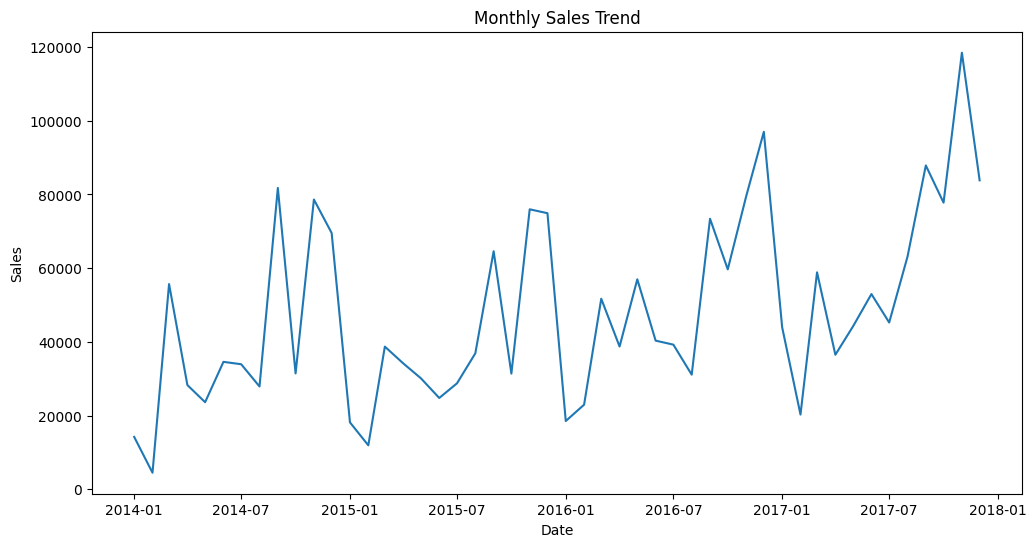

In [12]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()


In [13]:
sales_df = monthly_sales.reset_index()

In [14]:
sales_df.columns = ['Date', 'Sales']

In [15]:
sales_df['Month_Number'] = np.arange(len(sales_df))

In [16]:
sales_df.head()

,Date,Sales,Month_Number
0,2014-01-01,14236.895,0
1,2014-02-01,4519.892,1
2,2014-03-01,55691.009,2
3,2014-04-01,28295.345,3
4,2014-05-01,23648.287,4


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
X = sales_df[['Month_Number']]
y = sales_df['Sales']

In [19]:
model = LinearRegression()

In [20]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
predictions = model.predict(X)

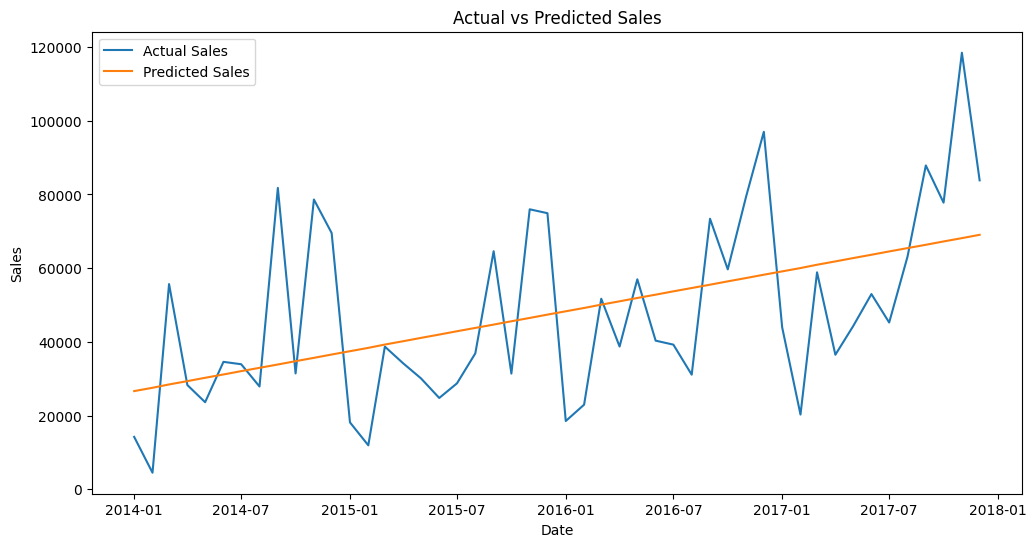

In [22]:
plt.figure(figsize=(12,6))

plt.plot(sales_df['Date'], y, label='Actual Sales')

plt.plot(sales_df['Date'], predictions, label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [23]:
future_months = np.arange(
    len(sales_df),
    len(sales_df) + 12
)

In [24]:
future_df = pd.DataFrame({
    'Month_Number': future_months
})

In [25]:
future_predictions = model.predict(future_df)

In [27]:
future_dates = pd.date_range(
    start=sales_df['Date'].max(),
    periods=13,
    freq='ME'
)[1:]

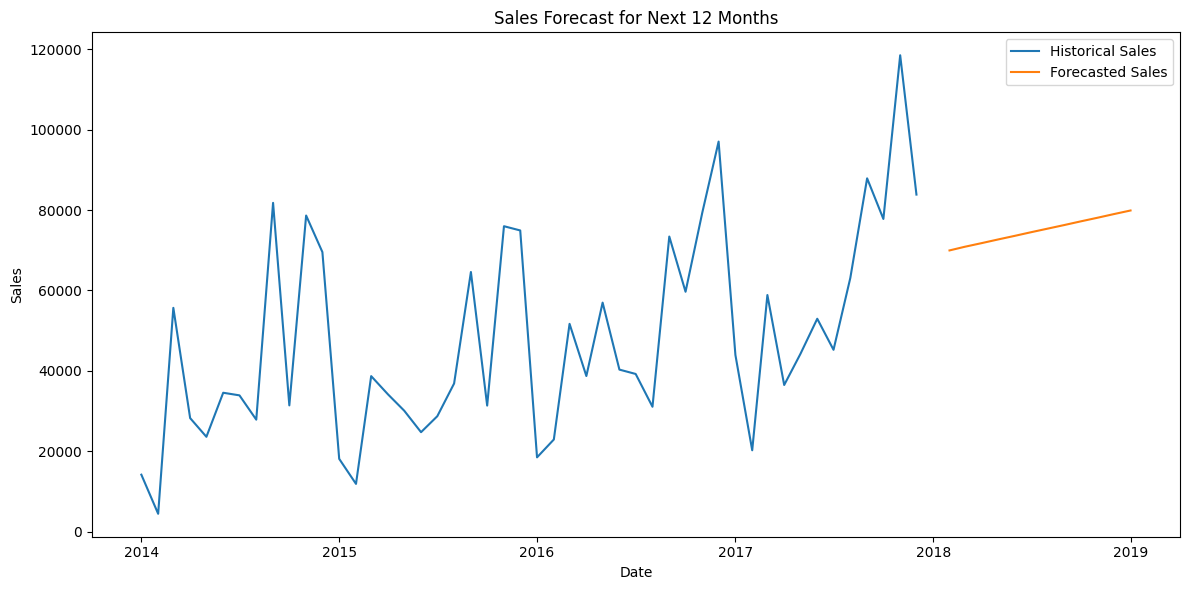

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    sales_df['Date'],
    sales_df['Sales'],
    label='Historical Sales'
)

plt.plot(
    future_dates,
    future_predictions,
    label='Forecasted Sales'
)

plt.title("Sales Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

In [29]:
forecast_df = pd.DataFrame({
    'Future Date': future_dates,
    'Predicted Sales': future_predictions
})

forecast_df

,Future Date,Predicted Sales
0,2018-01-31,69957.535798
1,2018-02-28,70859.543330
2,2018-03-31,71761.550862
3,2018-04-30,72663.558395
4,2018-05-31,73565.565927
5,2018-06-30,74467.573459
6,2018-07-31,75369.580992
7,2018-08-31,76271.588524
8,2018-09-30,77173.596056
9,2018-10-31,78075.603589


In [30]:
from sklearn.metrics import mean_absolute_error

In [31]:
mae = mean_absolute_error(y, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 17457.725724823373


In [32]:
forecast_df

,Future Date,Predicted Sales
0,2018-01-31,69957.535798
1,2018-02-28,70859.543330
2,2018-03-31,71761.550862
3,2018-04-30,72663.558395
4,2018-05-31,73565.565927
5,2018-06-30,74467.573459
6,2018-07-31,75369.580992
7,2018-08-31,76271.588524
8,2018-09-30,77173.596056
9,2018-10-31,78075.603589


In [33]:
plt.show()

In [34]:
plt.show()

In [36]:
plt.show()

In [38]:
plt.savefig("forecast_graph.png")

<Figure size 640x480 with 0 Axes>

In [39]:
plt.show()

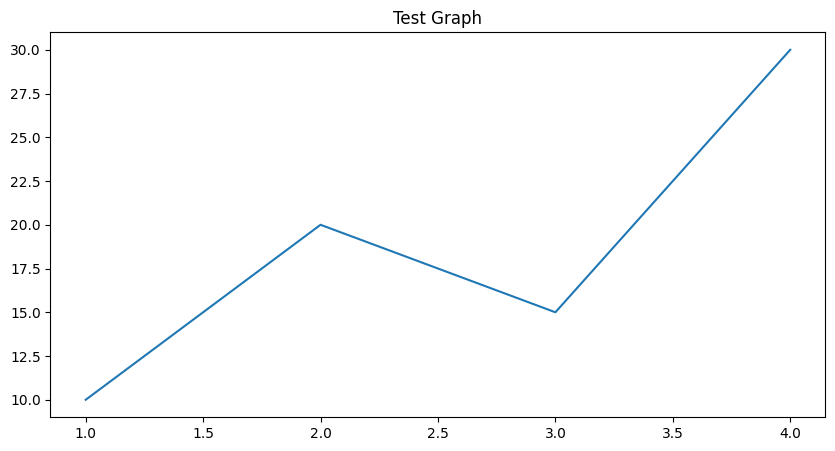

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot([1,2,3,4], [10,20,15,30])

plt.title("Test Graph")

plt.savefig("forecast_graph.png")

plt.show()